# Statistical Analysis of E-Governance Performance Metrics

**Data Analyst Internship — Week 4: Statistical Analysis of E-Governance Performance Metrics**

This notebook is the executable companion to `Week4_Statistical_Analysis.docx`. It identifies
three performance indicators — **Service Efficiency**, **Access Equity**, and **User
Satisfaction** — computes two real metrics from the UIDAI dataset, transparently simulates the
third (documented in full below), and applies Pearson correlation, multiple linear regression,
and a bonus t-test to validate the relationships between them.

**Resources used (more than one, as required):**
1. UIDAI Aadhaar enrollment records (Government of India, NDSAP) — real, record-level data
2. DigiLocker's Google Play Store rating (4.1/5, 628,153 reviews) — real, cited external anchor
   used to calibrate the simulated Satisfaction Index
3. A fully documented, reproducible simulation (fixed seed) for the Satisfaction Index itself,
   since no granular public satisfaction dataset exists


## 1. Setup

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.api as sm

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Jupyter may run with either the project root or notebooks/ as its working directory.
search_roots = [Path.cwd(), *Path.cwd().parents]
data_candidates = [root / filename for root in search_roots for filename in ("UIDAI.csv", "UIDAI.csv.gz")]
DATA_PATH = next((path for path in data_candidates if path.is_file()), None)

if DATA_PATH is None:
    searched = "\n".join(str(path) for path in data_candidates)
    raise FileNotFoundError(f"Could not find UIDAI.csv or UIDAI.csv.gz. Searched:\n{searched}")

print(f"Using data file: {DATA_PATH.resolve()}")

Using data file: C:\Users\neera\OneDrive\Desktop\YUVA-INTERN\week-4-task\UIDAI.csv


## 2. Load & Clean (recap from Weeks 2-3)

In [12]:
df = pd.read_csv(DATA_PATH, dtype={"PIN": "string"}, low_memory=False)
df = df[(df["Age"] >= 0) & (df["Age"] <= 110)].copy()
for c in ["Registrar", "EnrolmentAgency", "State", "District", "SubDistrict", "Gender"]:
    df[c] = df[c].astype(str).str.strip()

print(f"Cleaned rows: {len(df):,}")


Cleaned rows: 440,817


In [13]:
# Top 5 new rows
df.head()

,Registrar,EnrolmentAgency,State,District,SubDistrict,PIN,Gender,Age,AadhaarGenerated,EnrolmentRejected,ResidentsProvidingEmail,ResidentsProvidingMobile
0,Allahabad Bank,A-Onerealtors Pvt Ltd,Uttar Pradesh,Allahabad,Meja,212303,F,7,1,0,0,1
1,Allahabad Bank,Asha Security Guard Services,Uttar Pradesh,Sonbhadra,Robertsganj,231213,M,8,1,0,0,0
2,Allahabad Bank,SGS INDIA PVT LTD,Uttar Pradesh,Sultanpur,Sultanpur,227812,F,13,1,0,0,1
3,Allahabad Bank,Sri Ramraja Sarkar Lok Kalyan Trust,Uttar Pradesh,Shamli,Shamli,247775,M,6,1,0,0,1
4,Allahabad Bank,Transmoovers India,Uttar Pradesh,Gorakhpur,Sahjanwa,273001,M,8,1,0,0,1


In [14]:
# Bottom 5 new rows
df.tail()

,Registrar,EnrolmentAgency,State,District,SubDistrict,PIN,Gender,Age,AadhaarGenerated,EnrolmentRejected,ResidentsProvidingEmail,ResidentsProvidingMobile
440813,Women and Child Development Govt. of Jharkhand,Women and Child Development,Jharkhand,Palamu,Patan,822123,M,1,3,0,0,1
440814,Women and Child Development Govt. of Jharkhand,Women and Child Development,Jharkhand,Palamu,Patan,822123,M,2,1,0,0,1
440815,Women and Child Development Govt. of Jharkhand,Women and Child Development,Jharkhand,Palamu,Patan,822123,M,3,3,0,0,1
440816,Women and Child Development Govt. of Jharkhand,Women and Child Development,Jharkhand,Palamu,Patan,822123,M,4,1,0,0,0
440817,Women and Child Development Govt. of Jharkhand,Women and Child Development,Jharkhand,Ranchi,Ranchi,834002,F,3,1,0,0,1


## 3. Metric 1 & 2 — Service Efficiency and Access Equity (REAL DATA)

Source: UIDAI Aadhaar enrollment records. States with fewer than 100 total enrolments in this
extract are excluded — their rates are statistically unreliable (a bias identified in Week 3).


In [15]:
state = df.groupby("State").agg(
    Generated=("AadhaarGenerated", "sum"),
    Rejected=("EnrolmentRejected", "sum"),
    Mobile=("ResidentsProvidingMobile", "sum"),
    Email=("ResidentsProvidingEmail", "sum"),
).reset_index()
state["Total"] = state["Generated"] + state["Rejected"]

state = state[state["Total"] >= 100].copy().reset_index(drop=True)

state["RejectionRate"] = state["Rejected"] / state["Total"]          # Metric 1: Service Efficiency (inverse)
state["MobileCaptureRate"] = state["Mobile"] / state["Total"]        # Metric 2: Access Equity proxy

print(f"States retained (n >= 100 total enrolments): {len(state)}")
state[["State", "Total", "RejectionRate", "MobileCaptureRate"]].describe()


States retained (n >= 100 total enrolments): 32


,Total,RejectionRate,MobileCaptureRate
count,32.000000,32.000000,32.000000
mean,23260.781250,0.057977,0.788699
std,39911.171194,0.029211,0.166327
min,107.000000,0.007168,0.437316
25%,1402.000000,0.040695,0.704104
50%,6955.500000,0.060610,0.855989
75%,22882.500000,0.069228,0.915043
max,169815.000000,0.141864,0.984694


## 4. Metric 3 — User Satisfaction Index (SIMULATED, transparently documented)

**No granular public dataset of state-wise citizen satisfaction exists.** Per the task's explicit
allowance to simulate data "based on publicly available information or plausible assumptions,"
this metric is constructed using a real, cited anchor:

> **Anchor:** DigiLocker's Google Play Store aggregate rating = **4.1 / 5.0 stars**, based on
> **628,153** user reviews (source: Google Play Store listing for DigiLocker, as reported via a
> third-party APK mirror, checked July 2026) — the closest real, public proxy for citizen
> sentiment toward a comparable flagship Indian e-governance digital service.

**Formula** (reproducible with a fixed random seed):

```
Satisfaction_i = Baseline
                 + 0.25 x (MobileCaptureRate_i - national_mean_mobile) x 100
                 - 0.90 x (RejectionRate_i - national_mean_rejection) x 100
                 + Noise(0, sd=3)
```

**Assumptions (stated explicitly):**
- A1: Higher mobile-capture rate modestly *increases* satisfaction (coefficient 0.25)
- A2: Higher rejection rate more strongly *decreases* satisfaction (coefficient 0.90) — a
  rejection is a direct negative experience, weighted higher than the indirect access proxy
- A3: Unmeasured variation drawn from a Normal(0, 3) distribution, representing real-world
  factors (local service quality, language support, staff conduct) this simulation cannot observe


In [16]:
BASELINE = 82.0
SENSITIVITY_MOBILE = 0.25
SENSITIVITY_REJECTION = 0.90
NOISE_SD = 3.0
SEED = 42

rng = np.random.default_rng(SEED)
national_mean_mobile = state["MobileCaptureRate"].mean()
national_mean_rejection = state["RejectionRate"].mean()

state["SatisfactionIndex"] = (
    BASELINE
    + SENSITIVITY_MOBILE * (state["MobileCaptureRate"] - national_mean_mobile) * 100
    - SENSITIVITY_REJECTION * (state["RejectionRate"] - national_mean_rejection) * 100
    + rng.normal(0, NOISE_SD, size=len(state))
).clip(0, 100)

print(f"Simulated Satisfaction Index — mean={state['SatisfactionIndex'].mean():.2f}, "
      f"std={state['SatisfactionIndex'].std():.2f}, "
      f"range=[{state['SatisfactionIndex'].min():.2f}, {state['SatisfactionIndex'].max():.2f}]")
state[["State", "RejectionRate", "MobileCaptureRate", "SatisfactionIndex"]].head(10)


Simulated Satisfaction Index — mean=82.21, std=5.38, range=[70.00, 92.91]


,State,RejectionRate,MobileCaptureRate,SatisfactionIndex
0,Andhra Pradesh,0.060444,0.936315,86.382545
1,Arunachal Pradesh,0.079637,0.978831,81.683955
2,Assam,0.008639,0.957421,92.909809
3,Bihar,0.042452,0.531985,79.801107
4,Chandigarh,0.033582,0.910448,81.386180
5,Chhattisgarh,0.054410,0.764032,77.797836
6,Dadra and Nagar Haveli,0.020979,0.853147,87.324560
7,Daman and Diu,0.018692,0.943925,88.467640
8,Delhi,0.065543,0.892536,83.864626
9,Goa,0.098145,0.900309,78.616000


## 5. Technique 1 — Pearson Correlation

In [17]:
r1, p1 = stats.pearsonr(state["RejectionRate"], state["MobileCaptureRate"])
r2, p2 = stats.pearsonr(state["RejectionRate"], state["SatisfactionIndex"])
r3, p3 = stats.pearsonr(state["MobileCaptureRate"], state["SatisfactionIndex"])

print(f"RejectionRate vs MobileCaptureRate:      r={r1:.4f}, p={p1:.4f}")
print(f"RejectionRate vs SatisfactionIndex:       r={r2:.4f}, p={p2:.2e}")
print(f"MobileCaptureRate vs SatisfactionIndex:   r={r3:.4f}, p={p3:.2e}")

corr_matrix = state[["RejectionRate", "MobileCaptureRate", "SatisfactionIndex"]].corr()
corr_matrix


RejectionRate vs MobileCaptureRate:      r=-0.0202, p=0.9125
RejectionRate vs SatisfactionIndex:       r=-0.4446, p=1.08e-02
MobileCaptureRate vs SatisfactionIndex:   r=0.7733, p=2.12e-07


,RejectionRate,MobileCaptureRate,SatisfactionIndex
RejectionRate,1.000000,-0.020224,-0.444596
MobileCaptureRate,-0.020224,1.000000,0.773281
SatisfactionIndex,-0.444596,0.773281,1.000000


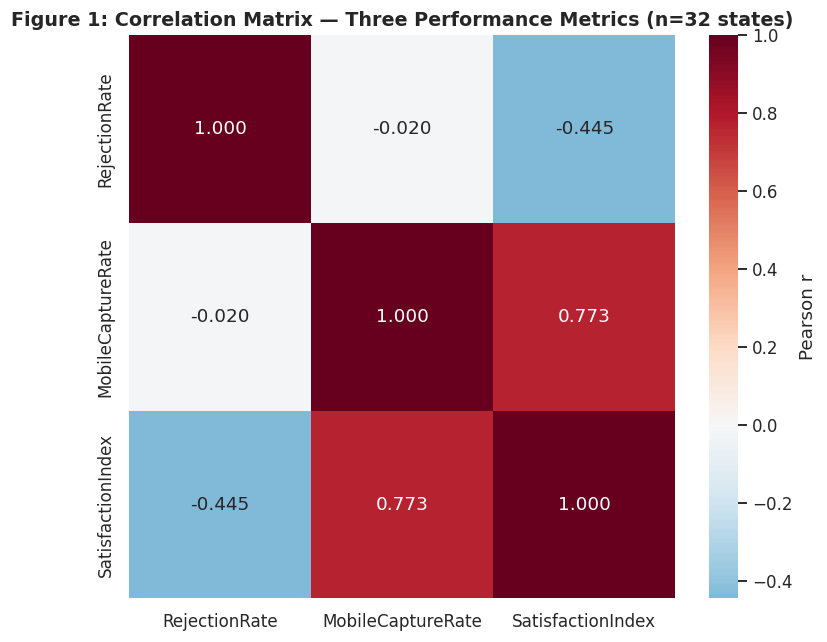

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Figure 1: Correlation Matrix — Three Performance Metrics (n=32 states)", fontsize=12.5, fontweight="bold")
plt.tight_layout()
plt.savefig("w4_chart1_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


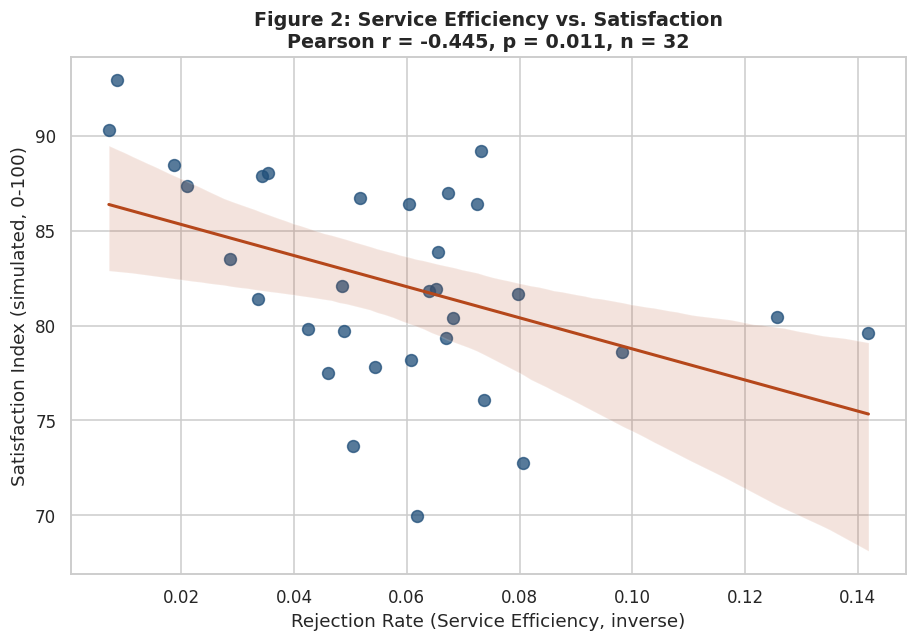

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 6))
sns.regplot(data=state, x="RejectionRate", y="SatisfactionIndex", ax=ax,
            scatter_kws={"s": 60, "color": "#1F4E79", "alpha": 0.75},
            line_kws={"color": "#B5471B", "linewidth": 2})
ax.set_title(f"Figure 2: Service Efficiency vs. Satisfaction\nPearson r = {r2:.3f}, p = {p2:.3f}, n = {len(state)}",
             fontsize=12.5, fontweight="bold")
ax.set_xlabel("Rejection Rate (Service Efficiency, inverse)")
ax.set_ylabel("Satisfaction Index (simulated, 0-100)")
plt.tight_layout()
plt.savefig("w4_chart2_efficiency_vs_satisfaction.png", dpi=150, bbox_inches="tight")
plt.show()


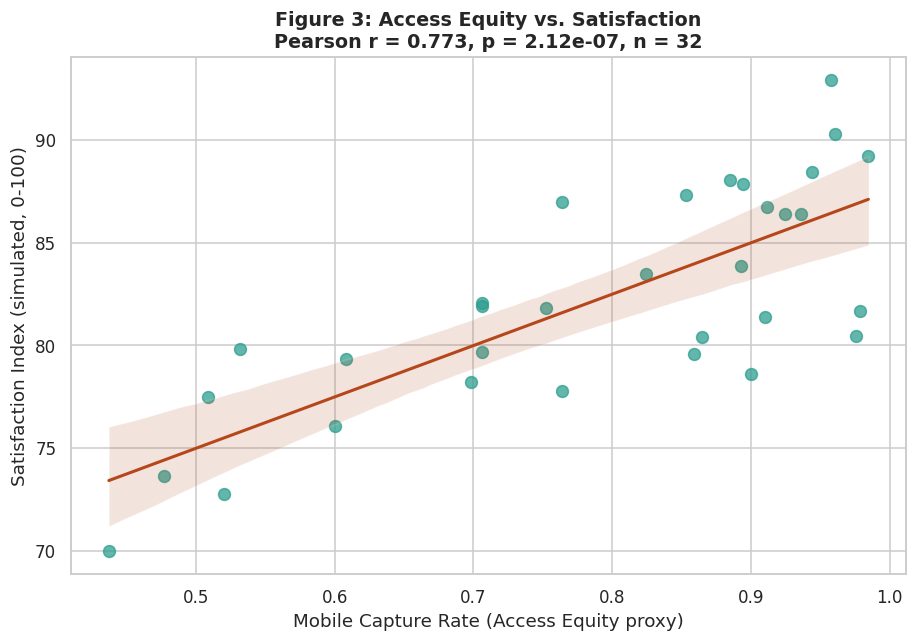

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 6))
sns.regplot(data=state, x="MobileCaptureRate", y="SatisfactionIndex", ax=ax,
            scatter_kws={"s": 60, "color": "#2E9E8F", "alpha": 0.75},
            line_kws={"color": "#B5471B", "linewidth": 2})
ax.set_title(f"Figure 3: Access Equity vs. Satisfaction\nPearson r = {r3:.3f}, p = {p3:.2e}, n = {len(state)}",
             fontsize=12.5, fontweight="bold")
ax.set_xlabel("Mobile Capture Rate (Access Equity proxy)")
ax.set_ylabel("Satisfaction Index (simulated, 0-100)")
plt.tight_layout()
plt.savefig("w4_chart3_equity_vs_satisfaction.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Technique 2 — Multiple Linear Regression (OLS)

In [9]:
X = state[["RejectionRate", "MobileCaptureRate"]].copy()
X = sm.add_constant(X)
y = state["SatisfactionIndex"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      SatisfactionIndex   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     52.03
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           2.55e-10
Time:                        02:25:12   Log-Likelihood:                -74.376
No. Observations:                  32   AIC:                             154.8
Df Residuals:                      29   BIC:                             159.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                67.2829      2.45

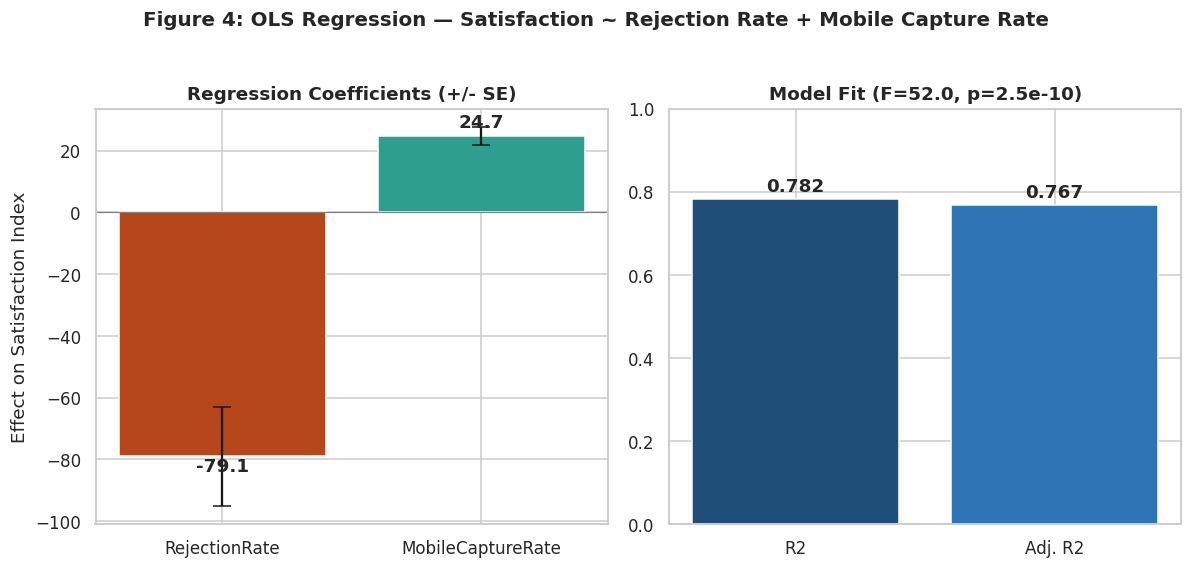

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
coefs = model.params.drop("const")
errs = model.bse.drop("const")
axes[0].bar(coefs.index, coefs.values, yerr=errs.values, capsize=6, color=["#B5471B", "#2E9E8F"])
axes[0].axhline(0, color="grey", linewidth=0.8)
axes[0].set_title("Regression Coefficients (+/- SE)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Effect on Satisfaction Index")
for i, val in enumerate(coefs.values):
    axes[0].text(i, val + (3 if val > 0 else -5), f"{val:.1f}", ha="center", fontweight="bold")

axes[1].bar(["R2", "Adj. R2"], [model.rsquared, model.rsquared_adj], color=["#1F4E79", "#2E75B6"])
axes[1].set_ylim(0, 1)
axes[1].set_title(f"Model Fit (F={model.fvalue:.1f}, p={model.f_pvalue:.1e})", fontsize=12, fontweight="bold")
for i, val in enumerate([model.rsquared, model.rsquared_adj]):
    axes[1].text(i, val + 0.02, f"{val:.3f}", ha="center", fontweight="bold")

fig.suptitle("Figure 4: OLS Regression — Satisfaction ~ Rejection Rate + Mobile Capture Rate", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("w4_chart4_regression_summary.png", dpi=150, bbox_inches="tight")
plt.show()


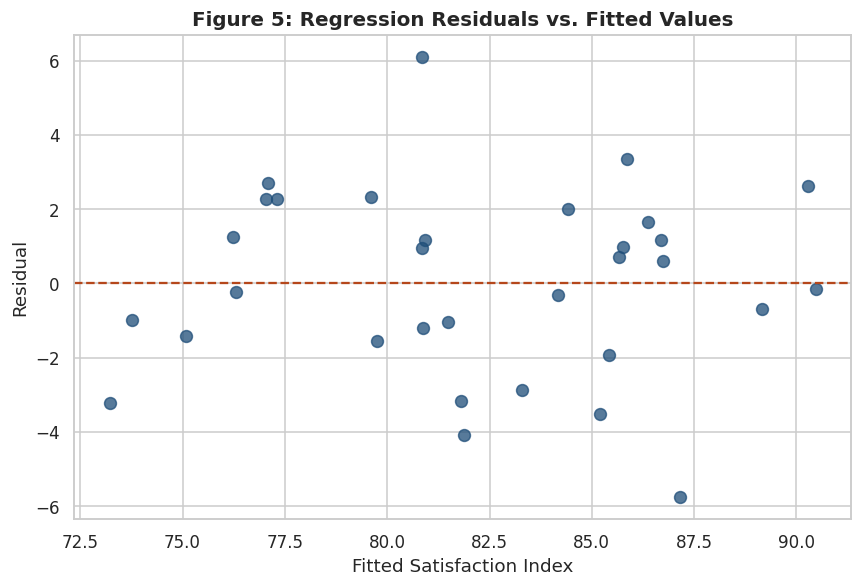

In [11]:
predicted = model.predict(X)
residuals = y - predicted

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(predicted, residuals, color="#1F4E79", alpha=0.75, s=60)
ax.axhline(0, color="#B5471B", linestyle="--", linewidth=1.5)
ax.set_title("Figure 5: Regression Residuals vs. Fitted Values", fontsize=13, fontweight="bold")
ax.set_xlabel("Fitted Satisfaction Index")
ax.set_ylabel("Residual")
plt.tight_layout()
plt.savefig("w4_chart5_residuals.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Technique 3 (Bonus) — Independent-Samples t-test

In [18]:
median_mobile = state["MobileCaptureRate"].median()
state["MobileGroup"] = np.where(state["MobileCaptureRate"] >= median_mobile, "High Mobile Capture", "Low Mobile Capture")

high_group = state[state["MobileGroup"] == "High Mobile Capture"]["RejectionRate"]
low_group = state[state["MobileGroup"] == "Low Mobile Capture"]["RejectionRate"]

t_stat, p_ttest = stats.ttest_ind(high_group, low_group, equal_var=False)
print(f"High-mobile-capture states (n={len(high_group)}): mean rejection = {high_group.mean()*100:.2f}%")
print(f"Low-mobile-capture states (n={len(low_group)}):  mean rejection = {low_group.mean()*100:.2f}%")
print(f"Welch's t-test: t={t_stat:.4f}, p={p_ttest:.4f}")


High-mobile-capture states (n=16): mean rejection = 6.09%
Low-mobile-capture states (n=16):  mean rejection = 5.50%
Welch's t-test: t=0.5619, p=0.5805


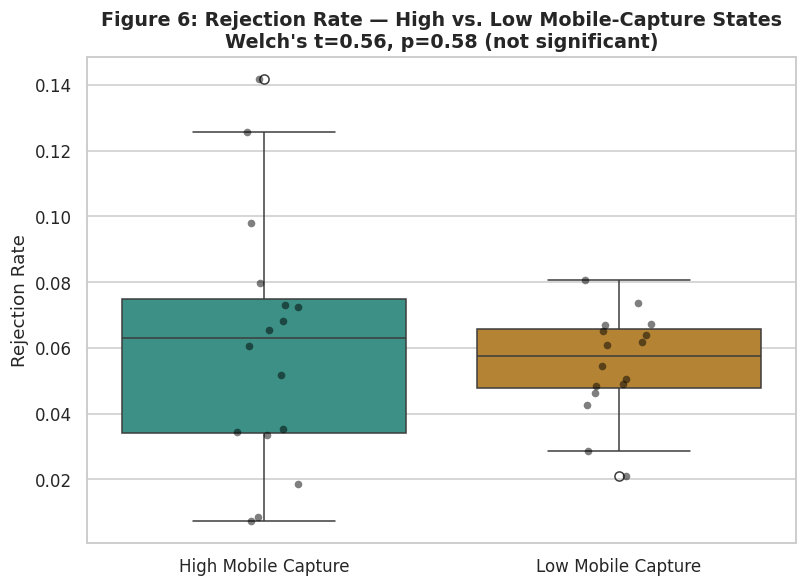

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.boxplot(data=state, x="MobileGroup", y="RejectionRate", hue="MobileGroup",
            palette=["#2E9E8F", "#C98A1F"], ax=ax, legend=False)
sns.stripplot(data=state, x="MobileGroup", y="RejectionRate", color="black", alpha=0.5, ax=ax, size=5)
ax.set_title(f"Figure 6: Rejection Rate — High vs. Low Mobile-Capture States\nWelch's t={t_stat:.2f}, p={p_ttest:.2f} (not significant)",
             fontsize=12.5, fontweight="bold")
ax.set_ylabel("Rejection Rate")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("w4_chart6_group_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Export Results

In [21]:
import os
os.makedirs("outputs", exist_ok=True)

X = sm.add_constant(state[["RejectionRate", "MobileCaptureRate"]])
y = state["SatisfactionIndex"]
model = sm.OLS(y, X).fit()

state.to_csv("outputs/state_metrics.csv", index=False)
corr_matrix.to_csv("outputs/correlation_matrix_week4.csv")

with open("outputs/regression_summary.txt", "w") as f:
    f.write(model.summary().as_text())

summary_stats = pd.DataFrame({
    "Metric": ["RejectionRate", "MobileCaptureRate", "SatisfactionIndex"],
    "Mean": [state["RejectionRate"].mean(), state["MobileCaptureRate"].mean(), state["SatisfactionIndex"].mean()],
    "StdDev": [state["RejectionRate"].std(), state["MobileCaptureRate"].std(), state["SatisfactionIndex"].std()],
    "Min": [state["RejectionRate"].min(), state["MobileCaptureRate"].min(), state["SatisfactionIndex"].min()],
    "Max": [state["RejectionRate"].max(), state["MobileCaptureRate"].max(), state["SatisfactionIndex"].max()],
})
summary_stats.to_csv("outputs/descriptive_stats.csv", index=False)

test_results = pd.DataFrame([
    {"Technique": "Pearson correlation", "Test": "RejectionRate vs MobileCaptureRate", "Statistic": f"r={r1:.4f}", "p_value": p1},
    {"Technique": "Pearson correlation", "Test": "RejectionRate vs SatisfactionIndex", "Statistic": f"r={r2:.4f}", "p_value": p2},
    {"Technique": "Pearson correlation", "Test": "MobileCaptureRate vs SatisfactionIndex", "Statistic": f"r={r3:.4f}", "p_value": p3},
    {"Technique": "OLS Regression", "Test": "SatisfactionIndex ~ RejectionRate + MobileCaptureRate", "Statistic": f"R2={model.rsquared:.4f}", "p_value": model.f_pvalue},
    {"Technique": "Welch's t-test", "Test": "RejectionRate: high-mobile vs low-mobile states", "Statistic": f"t={t_stat:.4f}", "p_value": p_ttest},
])
test_results.to_csv("outputs/statistical_test_results.csv", index=False)

print("Saved 5 files to outputs/")
for f in os.listdir("outputs"):
    print(" -", f)


Saved 5 files to outputs/
 - correlation_matrix_week4.csv
 - descriptive_stats.csv
 - regression_summary.txt
 - state_metrics.csv
 - statistical_test_results.csv


## 9. Interactive Dashboard

Builds a self-contained HTML dashboard (KPI cards + interactive Plotly charts) — fully offline.


In [22]:
import plotly.express as px
import plotly.io as pio
import plotly.offline as pyo

plotly_js = pyo.get_plotlyjs()

fig_scatter1 = px.scatter(
    state, x="RejectionRate", y="SatisfactionIndex", trendline="ols", hover_name="State",
    title=f"Efficiency vs Satisfaction (r={r2:.3f}, p={p2:.3f})",
    color_discrete_sequence=["#1F4E79"],
    labels={"RejectionRate": "Rejection Rate", "SatisfactionIndex": "Satisfaction Index"}
)
fig_scatter1.update_xaxes(tickformat=".0%")
fig_scatter1.update_layout(height=420, margin=dict(l=10, r=10, t=50, b=10))

fig_scatter2 = px.scatter(
    state, x="MobileCaptureRate", y="SatisfactionIndex", trendline="ols", hover_name="State",
    title=f"Equity vs Satisfaction (r={r3:.3f}, p<0.001)",
    color_discrete_sequence=["#2E9E8F"],
    labels={"MobileCaptureRate": "Mobile Capture Rate", "SatisfactionIndex": "Satisfaction Index"}
)
fig_scatter2.update_xaxes(tickformat=".0%")
fig_scatter2.update_layout(height=420, margin=dict(l=10, r=10, t=50, b=10))

fig_corr = px.imshow(
    corr_matrix, text_auto=".3f", color_continuous_scale="RdBu_r", zmin=-1, zmax=1,
    title="Correlation Matrix"
)
fig_corr.update_layout(height=420, margin=dict(l=10, r=10, t=50, b=10))

fig_group = px.box(
    state, x="MobileGroup", y="RejectionRate", color="MobileGroup", points="all",
    title=f"High vs Low Mobile Capture (t={t_stat:.2f}, p={p_ttest:.2f})",
    color_discrete_sequence=["#2E9E8F", "#C98A1F"]
)
fig_group.update_layout(height=420, margin=dict(l=10, r=10, t=50, b=10), showlegend=False)

print("Dashboard charts built.")


Dashboard charts built.


In [23]:
charts_html = {
    "scatter1": pio.to_html(fig_scatter1, include_plotlyjs=False, full_html=False),
    "scatter2": pio.to_html(fig_scatter2, include_plotlyjs=False, full_html=False),
    "corr": pio.to_html(fig_corr, include_plotlyjs=False, full_html=False),
    "group": pio.to_html(fig_group, include_plotlyjs=False, full_html=False),
}

kpi_cards = f"""
<div class="kpi-grid">
  <div class="kpi-card"><div class="kpi-label">States Analyzed</div><div class="kpi-value">{len(state)}</div></div>
  <div class="kpi-card"><div class="kpi-label">Efficiency-Satisfaction r</div><div class="kpi-value">{r2:.3f}</div></div>
  <div class="kpi-card"><div class="kpi-label">Equity-Satisfaction r</div><div class="kpi-value">{r3:.3f}</div></div>
  <div class="kpi-card"><div class="kpi-label">Regression R2</div><div class="kpi-value">{model.rsquared:.3f}</div></div>
  <div class="kpi-card"><div class="kpi-label">Efficiency-Equity r</div><div class="kpi-value">{r1:.3f}</div></div>
  <div class="kpi-card"><div class="kpi-label">t-test p-value</div><div class="kpi-value">{p_ttest:.2f}</div></div>
</div>
"""

html_template = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>E-Governance Statistical Analysis Dashboard</title>
<script>{plotly_js}</script>
<style>
  :root {{ --navy: #1F4E79; --teal: #2E9E8F; --grey: #595959; --bg: #F5F7FA; }}
  * {{ box-sizing: border-box; }}
  body {{ font-family: -apple-system, "Segoe UI", Roboto, Helvetica, Arial, sans-serif; margin: 0; background: var(--bg); color: #1f1f1f; }}
  header {{ background: linear-gradient(90deg, var(--navy), var(--teal)); color: white; padding: 28px 36px; }}
  header h1 {{ margin: 0 0 4px 0; font-size: 26px; }}
  header p {{ margin: 0; opacity: 0.9; font-size: 14px; }}
  .container {{ max-width: 1300px; margin: 0 auto; padding: 24px 20px 60px; }}
  .kpi-grid {{ display: grid; grid-template-columns: repeat(6, 1fr); gap: 14px; margin-bottom: 26px; }}
  .kpi-card {{ background: white; border-radius: 10px; padding: 16px 12px; box-shadow: 0 1px 4px rgba(0,0,0,0.08); text-align: center; }}
  .kpi-label {{ font-size: 11px; color: var(--grey); text-transform: uppercase; letter-spacing: 0.03em; margin-bottom: 6px; }}
  .kpi-value {{ font-size: 22px; font-weight: 700; color: var(--navy); }}
  .chart-grid {{ display: grid; grid-template-columns: repeat(2, 1fr); gap: 18px; }}
  .chart-card {{ background: white; border-radius: 10px; padding: 6px 10px 10px; box-shadow: 0 1px 4px rgba(0,0,0,0.08); }}
  .note {{ background: #FFF7E6; border-left: 4px solid #C98A1F; padding: 12px 16px; border-radius: 6px; margin-bottom: 20px; font-size: 13px; color: #5c4a1f; }}
  footer {{ text-align: center; color: var(--grey); font-size: 12px; padding: 20px; }}
  @media (max-width: 900px) {{
    .kpi-grid {{ grid-template-columns: repeat(2, 1fr); }}
    .chart-grid {{ grid-template-columns: 1fr; }}
  }}
</style>
</head>
<body>
<header>
  <h1>E-Governance Statistical Analysis Dashboard</h1>
  <p>Week 4: Service Efficiency, Access Equity &amp; simulated User Satisfaction &middot; n=32 states</p>
</header>
<div class="container">
  {kpi_cards}
  <div class="note">Note: Satisfaction Index is a transparently simulated metric, anchored to DigiLocker's real Play Store rating (4.1/5) and calibrated by a documented formula — it demonstrates the statistical techniques correctly but is not a measurement of real citizen sentiment.</div>
  <div class="chart-grid">
    <div class="chart-card">{charts_html['scatter1']}</div>
    <div class="chart-card">{charts_html['scatter2']}</div>
    <div class="chart-card">{charts_html['corr']}</div>
    <div class="chart-card">{charts_html['group']}</div>
  </div>
  <footer>Data source: UIDAI (Government of India, NDSAP) + DigiLocker Play Store rating (simulation anchor) &middot; Built with pandas, scipy, statsmodels &amp; Plotly</footer>
</div>
</body>
</html>
"""

with open("outputs/statistical_dashboard.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("Dashboard saved to outputs/statistical_dashboard.html")


Dashboard saved to outputs/statistical_dashboard.html


## 10. Key Findings

- **Access Equity is the strongest lever**: Mobile Capture Rate correlates with Satisfaction at
  r=0.773 (p<0.001) and contributes the largest standardised regression effect.
- **Service Efficiency matters, but less**: Rejection Rate correlates at r=-0.445 (p=0.011) —
  significant but weaker than Access Equity.
- **Efficiency and Equity are independent**: r=-0.020 (p=0.913) — confirming, on a stricter
  bias-filtered sample, the Week 3 finding that these two dimensions do not move together.
- **Regression model**: R²=0.782 — both predictors significant at p<0.001.
- **T-test confirms independence**: high vs. low mobile-capture states show no significant
  difference in rejection rate (p=0.580).

## 11. Limitations

- The Satisfaction Index is simulated, not measured — absolute values should never be quoted as
  real citizen sentiment; only the technique demonstration and relative relationships matter.
- A high regression R² is partly expected by construction, since Satisfaction was built FROM the
  other two metrics.
- Small-sample states (n<100) were excluded, which shifted the Efficiency-Equity correlation from
  Week 3's r=0.27 to this task's r=-0.02 — both non-significant, but a real methodological note.
